<a href="https://colab.research.google.com/github/MJMortensonWarwick/AdvancedDataAnalysis2526/blob/main/7_1_Optimised_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](https://drive.google.com/uc?export=view&id=1fCCk0L-CAJ6qDAMTMS0KbIP8VzZh_imB)

# 7.1 Optimised Dense Neural Network (with PyTorch)
This first Notebook will take us through building our second neural network - this time with extra tricks!

Our first task is importing the packages and checking the GPU:

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


You should see `device: cuda` indicating we are on GPU and all is good :)

We will be working with another classic dataset - the handwritten digits dataset popularised by Yann LeCunn (note a DNN may not be the best approach here - we will look at a couple of different options next week).

In this we have converted the data to a series of pixel values (numbers) where each pixel is between 0 (white) and 255 (black) - although we normalise this data as before. The images are 8*8 squares (8 pixels wide * 8 pixels height). We translate this to just 64 columns of data ... i.e. feature #0 is the first pixel and feature #63 is the last.

After this we no train test split. As `sklearn` has no option to split to three sets, we first separate the test data (15%) and then later split the remainder (`X_temp` and `y_temp`) into `X_train` and `X_val` (same for the $Y$ values).

Again, we convert everything into tensor format, $X$ as a float tensor and $Y$ as a long tensor, to work with pytorch.

Lastly we add everything into individual `DataLoader` variables to manage transfer to the model. We set a batch size of 64 (relatively arbitarily).

In [6]:
# Load the Digits dataset (8x8 images flattened to 64 features)
digits = load_digits()
X = digits.data
y = digits.target

# Split 1: Separate Test set (15%) from the rest (85%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Split 2: Separate Train (70% of total) and Validation (15% of total)
# 0.15 / 0.85 approx 0.176
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp)

# Scale the data (fit only on training data to prevent data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")

Training samples: 1257, Validation samples: 270, Test samples: 270


Next we specify the template for the model (before creating this as a variable/object). This is largely the same as last week, so refer back to there for a more detailed explanation.

However, we now have extra variables to set when an object is instantiated from this template. `input_dim` is as before (# of features). However, we are not doing binary but multiclass classification now, so also will have `num_classes` as a controllable parameter. Lastly, we set `dropout_rate` (the percentage of neurons we randomly turn off each time via the dropout layers) to be 0.2 as a default. You could change this (e.g. to 10%) by instantiating the model variable as:



```
`model = AdvancedDNN(input_dim=64, num_classes=10, droupout_rate=0.1)
```
By leaving it blank in the code below it will use the default we have set of 20%.



In [7]:
class AdvancedDNN(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.2):
        super(AdvancedDNN, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output Layer
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

model = AdvancedDNN(input_dim=64, num_classes=10).to(device)
print(model)

AdvancedDNN(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)


We specify loss crierion and optimiser as we did last week. Note we use `CrossEntropyLoss()` as this is multiclass. Also note we have used two methods for decaying the training. An in-built `weight_decay` for Adam, as well as `ReduceLROnPlateau` which drops the learning rate when validation loss slows.

In [8]:
criterion = nn.CrossEntropyLoss()

# AdamW adds weight decay directly to the weight update rule for better regularization
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning Rate Decay: Reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Now we will define the training loop as before. However, in line with the "extra tricks", there are a few extra things we need to do.

We have a new `patience` variable set as 5. This controls our early stopping mechanism. If the model goes 5 epochs without seeing improvement on validation performance, then the early stopping is triggered so we don't end up over-training (over-fitting). We also continually save the best model so we can revert back. We also have a step to continually reduce the learning rate.



In [9]:
epochs = 100
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

train_losses, val_losses = [], []

for epoch in range(epochs):
    if early_stop:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Update Learning Rate Scheduler based on validation loss
    scheduler.step(epoch_val_loss)

    # --- Early Stopping Logic ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stop = True

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

Epoch 005/100 | Train Loss: 0.4727 | Val Loss: 0.3843
Epoch 010/100 | Train Loss: 0.1845 | Val Loss: 0.1743
Epoch 015/100 | Train Loss: 0.1050 | Val Loss: 0.1245
Epoch 020/100 | Train Loss: 0.0631 | Val Loss: 0.0912
Epoch 025/100 | Train Loss: 0.0421 | Val Loss: 0.0643
Epoch 030/100 | Train Loss: 0.0421 | Val Loss: 0.0660
Early stopping triggered at epoch 30


We see the model stopped at 30 epochs, where the `Val Loss` has not improved on the performance from epoch 25 (results may change on different runs because of random numbers so don't be concerned if your results are slightly different).

We will now do testing on the test data. This again is similar to last week. However, there are a couple of changes. We load the best model from memory as above. We also print a nice `matplotlib`chart to view training over time.

Test Loss: 0.0878
Test Accuracy: 98.15%


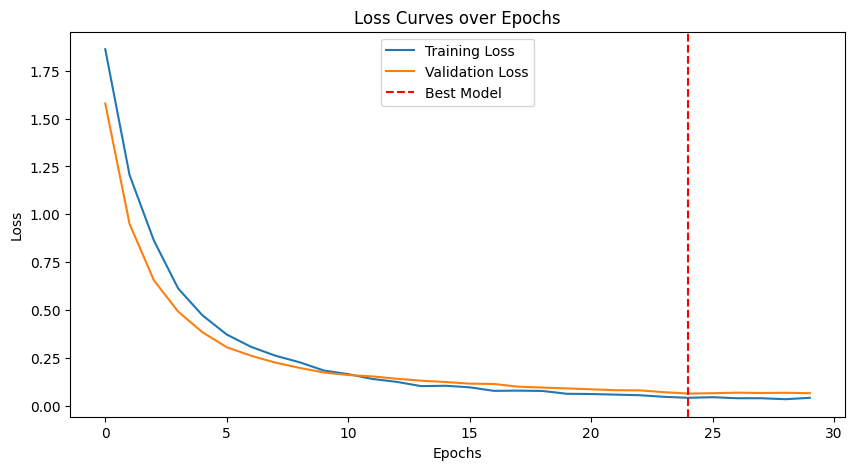

In [10]:
# Load the best model weights found during training
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Loss: {test_loss / len(test_loader.dataset):.4f}")
print(f"Test Accuracy: {(100 * correct / total):.2f}%")

# Plotting the learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=len(train_losses) - epochs_no_improve - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

As we can see we have a nice looking curve with validation loss slightly above training loss and seemingly not improving. Success!

### Exercises
Play around with some of hyperparameters here and see the effect. Some possible changes:


*   Number and type of layers;
*   Number of neurons in the dense layers;
* Dropout rate (as above);
* Optimiser (e.g. change to SGD);
* Learning rate (starting rate and decay amount);
* Patience;
* Batch size and epochs.

